In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------- USER INPUT --------
emory_file = "/hpc/home/yy450/link_kamaleswaranlab/EmoryDataset/EMR_RAW/2022/CJSEPSIS_CULTURES_2022.dsv"
mimic_file = "/hpc/home/yy450/link_kamaleswaranlab/mimic_iv/builtdata/csv_exports/hosp_microbiologyevents.csv"
# ----------------------------

# Load DataFrames
df_emory = pd.read_csv(emory_file, sep='|')
df_mimic = pd.read_csv(mimic_file)

print(f"✅ Loaded Emory: {df_emory.shape}, MIMIC: {df_mimic.shape}")
print(f"📋 Emory Columns: {list(df_emory.columns)}")
print(f"📋 MIMIC Columns: {list(df_mimic.columns)}")

# 🧪 Filter Emory by medication_id
# if "medication_id" not in df_emory.columns:
#     raise ValueError("'medication_id' column not found in Emory file.")

/tmp/ipykernel_1967961/1537273904.py:11: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_emory = pd.read_csv(emory_file, sep='|')
/tmp/ipykernel_1967961/1537273904.py:12: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mimic = pd.read_csv(mimic_file)


✅ Loaded Emory: (93641, 14), MIMIC: (3988224, 25)
📋 Emory Columns: ['pat_id', 'csn', 'proc_code', 'proc_desc', 'component_id', 'component', 'loinc_code', 'specimen_collect_time', 'order_time', 'order_id', 'result_id', 'lab_result_time', 'result_status', 'lab_result']
📋 MIMIC Columns: ['microevent_id', 'subject_id', 'hadm_id', 'micro_specimen_id', 'order_provider_id', 'chartdate', 'charttime', 'spec_itemid', 'spec_type_desc', 'test_seq', 'storedate', 'storetime', 'test_itemid', 'test_name', 'org_itemid', 'org_name', 'isolate_num', 'quantity', 'ab_itemid', 'ab_name', 'dilution_text', 'dilution_comparison', 'dilution_value', 'interpretation', 'comments']


In [70]:

# Emory analysis: list of medication IDs to filter by
# emory_medication_ids = [2208305]  # <-- 可以添加多个，例如 [2196639, 2196640, 2196641]
# emory_col = "tidal_volume_observed"

# MIMIC analysis: directly analyze this column
mimic_col = "gcs_unable"

In [71]:


# df_emory_filtered = df_emory[df_emory["medication_id"].isin(emory_medication_ids)]
# print(f"🔍 Emory rows after filtering by medication_id {emory_medication_ids}: {df_emory_filtered.shape[0]} rows")

# Check column existence
# if emory_col not in df_emory.columns:
#     raise ValueError(f"'{emory_col}' not found in Emory file.")
if mimic_col not in df_mimic.columns:
    raise ValueError(f"'{mimic_col}' not found in MIMIC file.")


# e_col = df_emory[emory_col]
# Extract target columns
# 强制转换
# e_col = pd.to_numeric(df_emory[emory_col], errors='coerce')

# 找出非数字的原始值
# invalid_values = df_emory.loc[e_col.isna(), emory_col].unique()
# print(f"🚨 None numeric type examples ({len(invalid_values)}):\n", invalid_values[:20])


# m_col = df_mimic[mimic_col]
m_col = df_mimic[mimic_col].astype(str)

In [72]:

# -- 1. Null Count --
print("\n🧼 Null Counts:")
# print(f"Emory - {emory_col}: {e_col.isnull().sum()} nulls out of {len(e_col)}")
print(f"MIMIC - {mimic_col}: {m_col.isnull().sum()} nulls out of {len(m_col)}")



🧼 Null Counts:
MIMIC - gcs_unable: 0 nulls out of 2217787


In [73]:
pd.options.display.float_format = '{:.4f}'.format

# -- 2. Summary Stats --
print("\n📊 Summary Statistics:")
# print("\nEmory:")
# display(e_col.describe(include='all'))
print("\nMIMIC:")
display(m_col.describe(include='all'))



📊 Summary Statistics:

MIMIC:


count     2217787
unique          2
top             0
freq      1432876
Name: gcs_unable, dtype: object

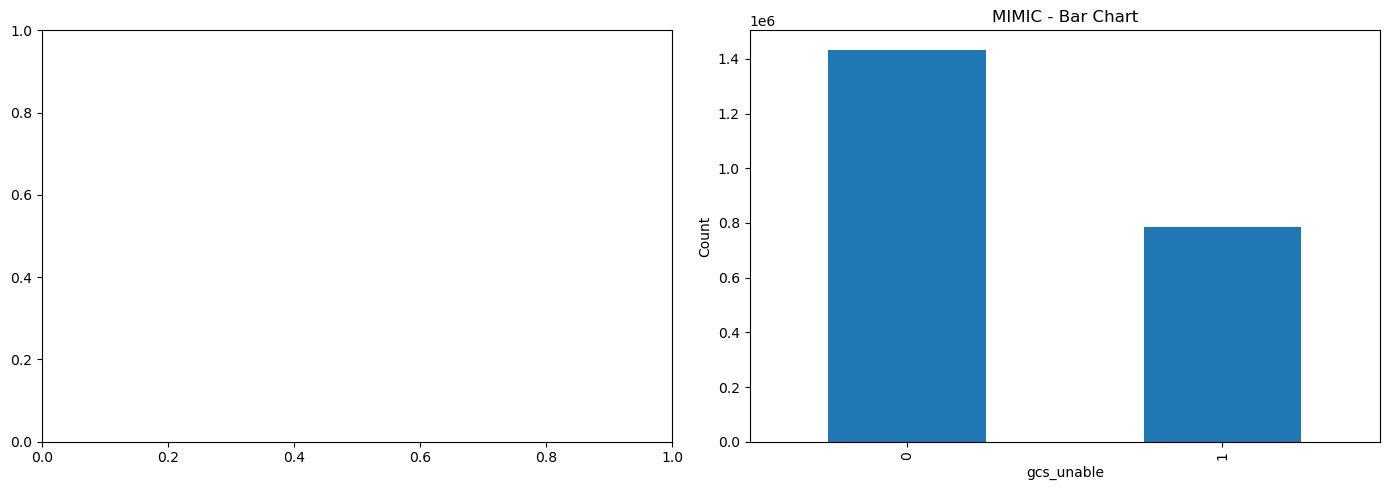

In [74]:
def plot_column_dist(col, source_name, ax, value_range=None):
    if pd.api.types.is_numeric_dtype(col):
        col_to_plot = col.dropna()
        if value_range:
            col_to_plot = col_to_plot[(col_to_plot >= value_range[0]) & (col_to_plot <= value_range[1])]
        sns.histplot(col_to_plot, kde=True, bins=50, ax=ax)
        ax.set_title(f"{source_name} - Histogram")
        ax.set_xlabel(col.name)
    else:
        col.value_counts().plot(kind='bar', ax=ax)
        ax.set_title(f"{source_name} - Bar Chart")
        ax.set_ylabel("Count")
        ax.set_xlabel(col.name)

value_range = (0, 1000)  # <- You can adjust this range based on expected values
# value_range = None  # <- No range filtering

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plot_column_dist(e_col, "Emory", axes[0], value_range=value_range)
plot_column_dist(m_col, "MIMIC", axes[1], value_range=value_range)
plt.tight_layout()
plt.show()


In [75]:

# -- 3.5 Unique Values (for non-numeric) --
# if not pd.api.types.is_numeric_dtype(e_col):
    # print(f"\n📋 Emory unique values in '{emory_col}':")
    # print(e_col.value_counts(dropna=False))

if not pd.api.types.is_numeric_dtype(m_col):
    print(f"\n📋 MIMIC unique values in '{mimic_col}':")
    print(m_col.value_counts(dropna=False))



📋 MIMIC unique values in 'gcs_unable':
gcs_unable
0    1432876
1     784911
Name: count, dtype: int64


In [76]:
if pd.api.types.is_numeric_dtype(m_col):
    plt.figure(figsize=(10, 5))

    # e_kde = e_col.dropna()
    m_kde = m_col.dropna()

    if value_range:
        # e_kde = e_kde[(e_kde >= value_range[0]) & (e_kde <= value_range[1])]
        m_kde = m_kde[(m_kde >= value_range[0]) & (m_kde <= value_range[1])]

    # sns.kdeplot(e_kde, label='Emory', fill=True)
    sns.kdeplot(m_kde, label='MIMIC', fill=True)
    plt.title(f"Emory ({emory_col}) vs MIMIC ({mimic_col}) - KDE Overlay")
    plt.xlabel("Value")
    plt.legend()
    plt.show()
else:
    print("\n⚠️ Skipping side-by-side KDE plot: one or both columns are not numeric.")



⚠️ Skipping side-by-side KDE plot: one or both columns are not numeric.
